In [ ]:
# Cell 1: Install libraries (takes ~1-2 minutes)
!pip install -q timm albumentations peft grad-cam wandb kaggle opencv-python-headless matplotlib seaborn scikit-learn

# After install, you may need to restart the runtime.
# If Colab asks, click "Restart Runtime" and run this cell again to confirm.
print("✅ Libraries installed.")

✅ Libraries installed.


In [ ]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create a folder for our project
import os
PROJECT_DIR = '/content/drive/MyDrive/Retinal_ViT_Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'checkpoints'), exist_ok=True)
print(f"✅ Project folder ready at: {PROJECT_DIR}")

Mounted at /content/drive
✅ Project folder ready at: /content/drive/MyDrive/Retinal_ViT_Project


In [ ]:
# Recovery cell for Steps 3–10 (Multi‑Disease System)
import os, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Also re‑define the previous helper if needed
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

Device: cpu


Train: 2930 images
Val:   366 images
Test:  366 images
Using image directory: /content/drive/MyDrive/aptos2019/train_images/train_images
✅ Successfully read a test image of shape (2136, 3216, 3)


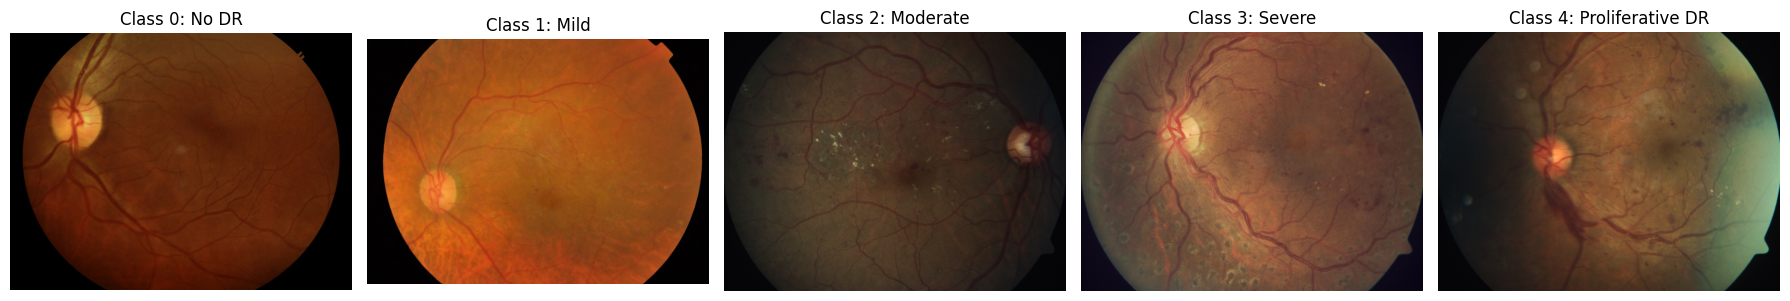

In [ ]:
# Cell 6 – Corrected EDA with nested folder
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os

base = "/content/drive/MyDrive/aptos2019"

train_df = pd.read_csv(f"{base}/train_1.csv")
val_df   = pd.read_csv(f"{base}/valid.csv")
test_df  = pd.read_csv(f"{base}/test.csv")

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test:  {len(test_df)} images")

# The actual image path has an extra level
img_dir = os.path.join(base, "train_images", "train_images")   # adjust this
print(f"Using image directory: {img_dir}")

# Check we can read one image
sample_id = train_df.iloc[0]['id_code'] + '.png'
sample_path = os.path.join(img_dir, sample_id)
test_img = cv2.imread(sample_path)
if test_img is None:
    print(f"❌ Still cannot read {sample_path}")
else:
    print(f"✅ Successfully read a test image of shape {test_img.shape}")

class_names = {0:'No DR', 1:'Mild', 2:'Moderate', 3:'Severe', 4:'Proliferative DR'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, c in enumerate(sorted(train_df['diagnosis'].unique())):
    sample = train_df[train_df['diagnosis'] == c].sample(1, random_state=42).iloc[0]
    img_path = os.path.join(img_dir, f"{sample['id_code']}.png")
    img = cv2.imread(img_path)
    if img is None:
        print(f"Missing image: {img_path}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f"Class {c}: {class_names[c]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import os
base = "/content/drive/MyDrive/aptos2019"
print("train_images contents:", os.listdir(f"{base}/train_images"))
print("val_images contents:", os.listdir(f"{base}/val_images") if os.path.exists(f"{base}/val_images") else "NO VAL DIR")
print("test_images contents:", os.listdir(f"{base}/test_images") if os.path.exists(f"{base}/test_images") else "NO TEST DIR")

train_images contents: ['train_images']
val_images contents: ['val_images']
test_images contents: ['test_images']


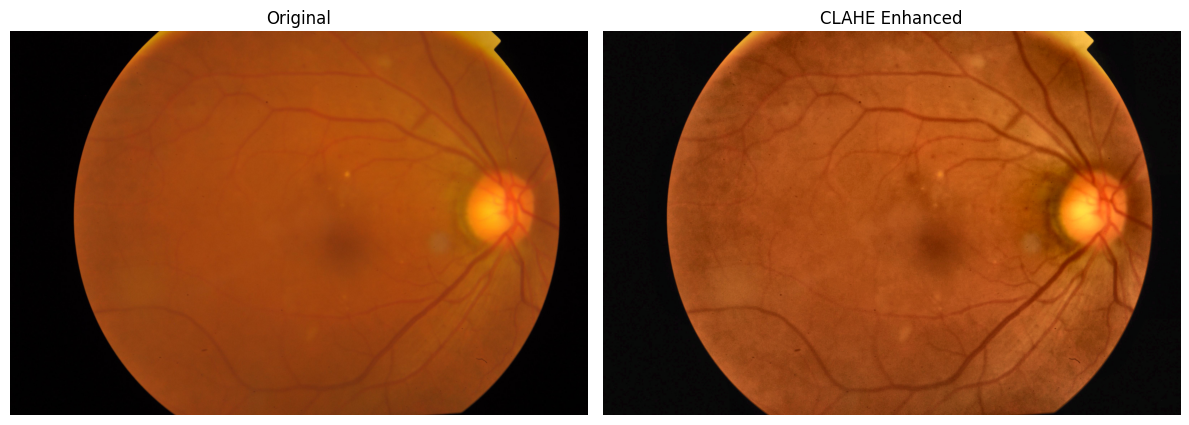

In [ ]:
# Cell 9 – CLAHE enhancement and visualisation
import cv2
import matplotlib.pyplot as plt
import os

def apply_clahe(img_rgb, clip_limit=2.0, tile_grid_size=(8,8)):
    """
    Apply CLAHE to the L channel of an RGB image.
    Args:
        img_rgb: numpy array, RGB image
    Returns:
        enhanced RGB image
    """
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

# Show a before/after example
base = "/content/drive/MyDrive/aptos2019"
img_dir = os.path.join(base, "train_images", "train_images")  # adjust if needed
sample_id = train_df.iloc[0]['id_code'] + '.png'
sample_path = os.path.join(img_dir, sample_id)

original = cv2.imread(sample_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
clahe_enhanced = apply_clahe(original)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(original)
ax1.set_title('Original')
ax1.axis('off')
ax2.imshow(clahe_enhanced)
ax2.set_title('CLAHE Enhanced')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 10 – Augmentation pipelines and custom Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset

# ---- Albumentations transforms ----
train_transform = A.Compose([
    A.Resize(224, 224),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=30, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=1.0),  # always apply
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ---- Helper: get correct nested image folder ----
def get_img_subdir(root, folder_name):
    """Returns the actual path to images, handling nested folders."""
    path = os.path.join(root, folder_name)
    # Check if it contains a subfolder with same name
    if os.path.isdir(path) and len(os.listdir(path)) == 1:
        sub = os.listdir(path)[0]
        if os.path.isdir(os.path.join(path, sub)):
            return os.path.join(path, sub)
    return path

# ---- Retinal Dataset ----
class RetinalDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['id_code'] + '.png')
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        return image, torch.tensor(row['diagnosis'], dtype=torch.long)

In [ ]:
# Cell 11 – Create DataLoaders
base = "/content/drive/MyDrive/aptos2019"

# Use helper to get correct image paths
train_img_dir = get_img_subdir(base, "train_images")
val_img_dir   = get_img_subdir(base, "val_images")
test_img_dir  = get_img_subdir(base, "test_images")

print("Train image path:", train_img_dir)
print("Val   image path:", val_img_dir)
print("Test  image path:", test_img_dir)

# Datasets
train_dataset = RetinalDataset(train_df, train_img_dir, transform=train_transform)
val_dataset   = RetinalDataset(val_df,   val_img_dir,   transform=val_test_transform)
test_dataset  = RetinalDataset(test_df,  test_img_dir,  transform=val_test_transform)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train image path: /content/drive/MyDrive/aptos2019/train_images/train_images
Val   image path: /content/drive/MyDrive/aptos2019/val_images/val_images
Test  image path: /content/drive/MyDrive/aptos2019/test_images/test_images
Batches - Train: 92, Val: 12, Test: 12


In [ ]:
# Cell 14 – Training Utilities (FocalLoss + evaluate) – self-contained
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

# Recompute class weights (in case variable was lost)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights.cpu().numpy())

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        else:
            loss = (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return loss.mean()
        return loss.sum() if self.reduction == 'sum' else loss

criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(device)
print("✅ FocalLoss ready.")

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    try:
        auc_macro = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_macro = 0.0
    pred_labels = all_probs.argmax(axis=1)
    acc = (pred_labels == all_labels).mean()
    qwk = cohen_kappa_score(all_labels, pred_labels, weights='quadratic')
    return avg_loss, auc_macro, qwk, acc, all_probs, all_labels

print("✅ evaluate() ready.")

Class weights: [0.40864715 1.9533334  0.7252475  3.8051949  2.5042734 ]
✅ FocalLoss ready.
✅ evaluate() ready.


In [ ]:
# Recovery – build RetinalViT model
class RetinalViT(nn.Module):
    def __init__(self, num_classes=5, model_name='vit_base_patch16_224', pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.embed_dim = self.backbone.embed_dim
        self.head = nn.Linear(self.embed_dim, num_classes)
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)
    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
    def unfreeze_last_n_blocks(self, n):
        for blk in self.backbone.blocks[-n:]:
            for param in blk.parameters():
                param.requires_grad = True
    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

model = RetinalViT(num_classes=5).to(device)
print(f"✅ Model ready. Params: {sum(p.numel() for p in model.parameters()):,}")

✅ Model ready. Params: 85,802,501


In [ ]:
# Recovery – re-load data and re-create criterion
base = "/content/drive/MyDrive/aptos2019"
train_df = pd.read_csv(f"{base}/train_1.csv")

# Class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis'].values)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# FocalLoss and evaluate (same as before)
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        else:
            loss = (1 - pt) ** self.gamma * ce_loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()

criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(device)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    try:
        auc_macro = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_macro = 0.0
    pred_labels = all_probs.argmax(axis=1)
    acc = (pred_labels == all_labels).mean()
    qwk = cohen_kappa_score(all_labels, pred_labels, weights='quadratic')
    return avg_loss, auc_macro, qwk, acc, all_probs, all_labels

print("✅ Criterion & evaluate ready.")

✅ Criterion & evaluate ready.


In [ ]:
# Cell 15 – Fast training: 3 short phases
import torch.amp
from tqdm import tqdm

# Settings for each phase (reduced epochs)
phases = [
    {"name": "Phase A (head)", "lr": 1e-3, "epochs": 2, "unfreeze": "head"},
    {"name": "Phase B (last 4 blocks)", "lr": 1e-5, "epochs": 2, "unfreeze": "blocks", "n_blocks": 4},
    {"name": "Phase C (full)", "lr": 1e-6, "epochs": 2, "unfreeze": "all"},
]

history = {'train_loss':[], 'val_loss':[], 'val_auc':[], 'val_qwk':[], 'phase':[]}
PROJECT_DIR = "/content/drive/MyDrive/Retinal_ViT_Project"
os.makedirs(f"{PROJECT_DIR}/checkpoints", exist_ok=True)

for phase in phases:
    print(f"\n{'='*50}\n   {phase['name']}\n{'='*50}")
    # Set trainable parameters
    if phase['unfreeze'] == 'head':
        model.freeze_backbone()
        optimizer = optim.AdamW(model.head.parameters(), lr=phase['lr'], weight_decay=0.01)
    elif phase['unfreeze'] == 'blocks':
        model.unfreeze_last_n_blocks(phase['n_blocks'])
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=phase['lr'])
    else:  # all
        model.unfreeze_all()
        optimizer = optim.AdamW(model.parameters(), lr=phase['lr'])

    scaler = torch.amp.GradScaler()
    best_qwk = 0.0

    for epoch in range(1, phase['epochs']+1):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{phase['epochs']}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_dataset)
        val_loss, auc, qwk, acc, _, _ = evaluate(model, val_loader, criterion)

        # Log
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(auc)
        history['val_qwk'].append(qwk)
        history['phase'].append(phase['name'])

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | AUC: {auc:.4f} | QWK: {qwk:.4f} | Acc: {acc:.4f}")

        # Save best in phase
        if qwk > best_qwk:
            best_qwk = qwk
            torch.save(model.state_dict(), f"{PROJECT_DIR}/checkpoints/{phase['name'].replace(' ','_')}_best.pth")

print("\n✅ All phases completed. Best QWK per phase were saved.")


   Phase A (head)


Epoch 1/2: 100%|██████████| 92/92 [04:53<00:00,  3.19s/it]


Epoch 1 | Train Loss: 0.5127 | Val Loss: 0.4812 | AUC: 0.9266 | QWK: 0.8727 | Acc: 0.8005


Epoch 2/2: 100%|██████████| 92/92 [04:36<00:00,  3.01s/it]


Epoch 2 | Train Loss: 0.5464 | Val Loss: 0.5119 | AUC: 0.9196 | QWK: 0.8292 | Acc: 0.7322

   Phase B (last 4 blocks)


...

Epoch 2 | Train Loss: 0.4239 | Val Loss: 0.4314 | AUC: 0.9314 | QWK: 0.8848 | Acc: 0.7923

   Phase C (full)


Epoch 1/2: 100%|██████████| 92/92 [04:46<00:00,  3.12s/it]


Epoch 1 | Train Loss: 0.4031 | Val Loss: 0.4458 | AUC: 0.9207 | QWK: 0.8489 | Acc: 0.7295


Epoch 2/2: 100%|██████████| 92/92 [04:42<00:00,  3.07s/it]


Epoch 2 | Train Loss: 0.3871 | Val Loss: 0.4200 | AUC: 0.9318 | QWK: 0.8906 | Acc: 0.7951

✅ All phases completed. Best QWK per phase were saved.


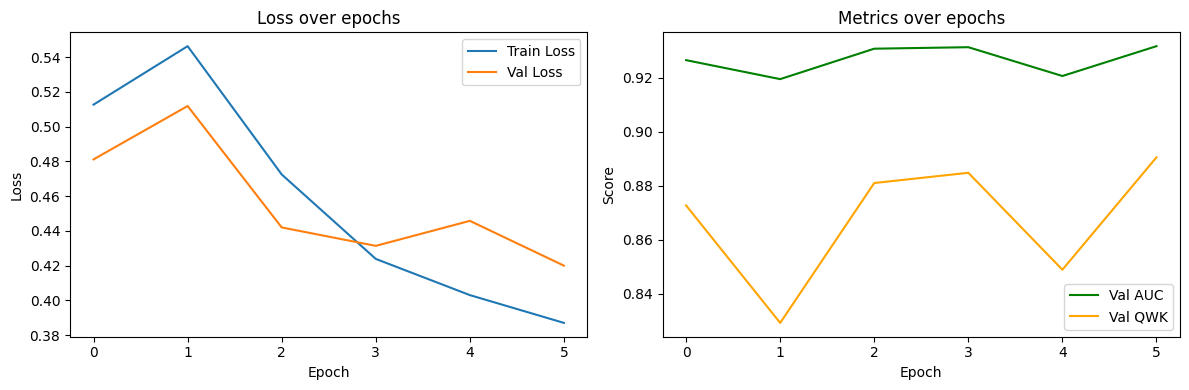

In [ ]:
# Cell 16 – Plot combined training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_auc'], label='Val AUC', color='green')
plt.plot(history['val_qwk'], label='Val QWK', color='orange')
plt.title('Metrics over epochs')
plt.xlabel('Epoch'); plt.ylabel('Score'); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17 – Load best checkpoint (from final phase) and evaluate on test set
best_path = f"{PROJECT_DIR}/checkpoints/Phase_C_(full)_best.pth"
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best checkpoint from Phase C.")
else:
    print("No checkpoint found – using current model.")

test_loss, test_auc, test_qwk, test_acc, test_probs, test_labels = evaluate(model, test_loader, criterion)
print(f"\n📊 Test Results:")
print(f"   Loss: {test_loss:.4f}")
print(f"   AUC (macro): {test_auc:.4f}")
print(f"   QWK: {test_qwk:.4f}")
print(f"   Accuracy: {test_acc:.4f}")

Loaded best checkpoint from Phase C.

📊 Test Results:
   Loss: 0.4160
   AUC (macro): 0.9306
   QWK: 0.8852
   Accuracy: 0.7923



Classification Report:
               precision    recall  f1-score   support

        No DR       0.98      0.97      0.98       199
         Mild       0.51      0.63      0.57        30
     Moderate       0.77      0.62      0.69        87
       Severe       0.23      0.47      0.31        17
Proliferative       0.56      0.45      0.50        33

     accuracy                           0.79       366
    macro avg       0.61      0.63      0.61       366
 weighted avg       0.82      0.79      0.80       366



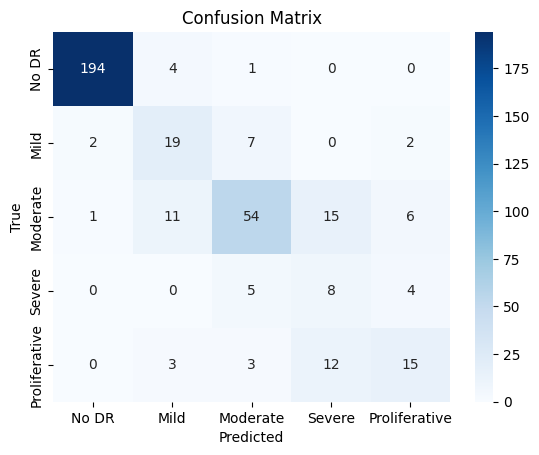

In [ ]:
# Cell 18 – Confusion matrix and report
preds = np.argmax(test_probs, axis=1)
print("\nClassification Report:")
print(classification_report(test_labels, preds, target_names=['No DR','Mild','Moderate','Severe','Proliferative']))

sns.heatmap(confusion_matrix(test_labels, preds), annot=True, fmt='d',
            xticklabels=['No DR','Mild','Moderate','Severe','Proliferative'],
            yticklabels=['No DR','Mild','Moderate','Severe','Proliferative'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.show()

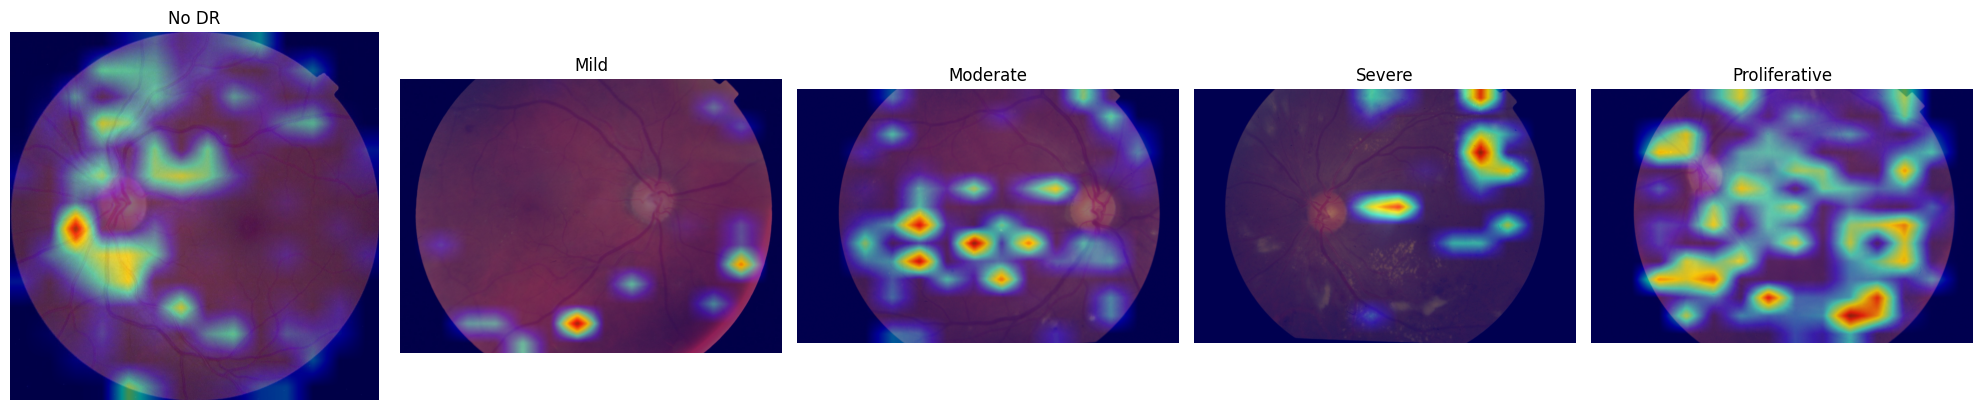

In [ ]:
# Cell 19 – Grad‑CAM for all 5 DR grades (fixed resizing)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def reshape_transform(tensor, height=14, width=14):
    # Remove class token, keep only patch tokens -> (batch, 196, embed_dim)
    result = tensor[:, 1:, :]
    result = result.reshape(tensor.size(0), height, width, tensor.size(-1))
    result = result.permute(0, 3, 1, 2)  # (batch, embed_dim, height, width)
    return result

target_layers = [model.backbone.blocks[-1].norm1]
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

# Validation transform (resize to 224)
val_tr = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

base = "/content/drive/MyDrive/aptos2019"
test_img_folder = get_img_subdir(base, "test_images")

preds = np.argmax(test_probs, axis=1)   # from earlier test evaluation
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, grade in enumerate(range(5)):
    correct_idx = np.where((test_labels == grade) & (preds == grade))[0]
    if len(correct_idx) == 0:
        axes[i].text(0.5, 0.5, 'No correct\nsample', ha='center', va='center')
        axes[i].set_title(class_names[grade])
        axes[i].axis('off')
        continue

    idx = correct_idx[0]
    sample_id = test_df.iloc[idx]['id_code']
    img_path = os.path.join(test_img_folder, sample_id + '.png')
    if not os.path.exists(img_path):
        img_path = os.path.join(train_img_dir, sample_id + '.png')

    # Load original size image (in RGB)
    orig_img = cv2.imread(img_path)
    if orig_img is None:
        axes[i].text(0.5, 0.5, 'Image not\nfound', ha='center', va='center')
        axes[i].set_title(class_names[grade])
        axes[i].axis('off')
        continue
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    h, w = orig_img.shape[:2]

    # Prepare model input (resized)
    input_tensor = val_tr(image=orig_img)['image'].unsqueeze(0).to(device)

    # Generate heatmap (size = 224x224 because input is 224x224)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(grade)])
    heatmap = grayscale_cam[0, :]   # shape: (224, 224)

    # Upsample heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, (w, h))

    # Overlay on original image (normalised to [0,1])
    vis = show_cam_on_image(orig_img / 255.0, heatmap_resized, use_rgb=True)

    axes[i].imshow(vis)
    axes[i].set_title(class_names[grade])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 20 – Export results and ONNX (final clean version)
import json

# (results JSON already saved – we can confirm)
print("✅ Results JSON saved earlier.")

# Install missing onnxscript
!pip install -q onnxscript

# ONNX export
dummy_input = torch.randn(1, 3, 224, 224).to(device)
onnx_path = f"{PROJECT_DIR}/retinal_vit.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
    opset_version=13
)
print(f"✅ ONNX model exported to {onnx_path}")

# (Optional) trace method instead of script – but ONNX is enough
# traced = torch.jit.trace(model, dummy_input)
# torch.jit.save(traced, f"{PROJECT_DIR}/retinal_vit_traced.pt")
# print("✅ Traced model saved (backup)")

✅ Results JSON saved earlier.


W0508 04:22:44.725000 11247 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0508 04:22:45.234000 11247 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0508 04:22:45.236000 11247 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ra

[torch.onnx] Obtain model graph for `RetinalViT([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RetinalViT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/no_previous_version.h:24: adapt: Assertion `

[torch.onnx] Translate the graph into ONNX... ✅
✅ ONNX model exported to /content/drive/MyDrive/Retinal_ViT_Project/retinal_vit.onnx


In [ ]:
!pip install fastapi uvicorn python-multipart onnxruntime albumentations opencv-python-headless pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 59.3 MB/s eta 0:00:00


In [ ]:
# Write the FastAPI server code to a file in your project directory
api_code = """
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import onnxruntime as ort
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
from PIL import Image
import io

# Constants
MODEL_PATH = "/content/drive/MyDrive/Retinal_ViT_Project/retinal_vit.onnx"
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

# Load ONNX model (use CPU for simplicity; can switch to CUDAExecutionProvider)
session = ort.InferenceSession(MODEL_PATH, providers=['CPUExecutionProvider'])

# Preprocessing exactly as during training validation
transform = A.Compose([
    A.Resize(224, 224),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

app = FastAPI(title="Retinal Disease Classifier", version="1.0")

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # Read image from upload
    contents = await file.read()
    nparr = np.frombuffer(contents, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    if img is None:
        return JSONResponse(content={"error": "Invalid image"}, status_code=400)

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    transformed = transform(image=img)
    input_tensor = transformed['image'].unsqueeze(0).numpy()

    # Inference
    outputs = session.run(None, {'input': input_tensor})
    logits = outputs[0][0]   # shape (5,)
    probs = softmax(logits)

    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    return {
        "class": CLASS_NAMES[pred_idx],
        "confidence": confidence,
        "probabilities": {
            CLASS_NAMES[i]: float(probs[i]) for i in range(5)
        }
    }

@app.get("/health")
async def health():
    return {"status": "healthy"}
"""

# Save the file
with open("/content/drive/MyDrive/Retinal_ViT_Project/retinopathy_api.py", "w") as f:
    f.write(api_code)
print("✅ API file saved to Drive.")

✅ API file saved to Drive.


In [ ]:
!pip install pyngrok

In [ ]:
import nest_asyncio
import uvicorn
import threading
import requests
import time

nest_asyncio.apply()

def run_api():
    # Point uvicorn to the module path in Drive
    uvicorn.run(
        "retinopathy_api:app",
        host="127.0.0.1",
        port=8000,
        reload=False,
        # We need to tell uvicorn where to find the Python file
        app_dir="/content/drive/MyDrive/Retinal_ViT_Project"
    )

# Use app_dir argument by modifying the import path
# Actually, a simpler way: change working directory
import sys
sys.path.insert(0, "/content/drive/MyDrive/Retinal_ViT_Project")

thread = threading.Thread(target=run_api, daemon=True)
thread.start()
time.sleep(3)   # give server time to start
print("✅ Server started at http://127.0.0.1:8000")

✅ Server started at http://127.0.0.1:8000


In [ ]:
import os

base = "/content/drive/MyDrive/aptos2019"

# Check which folders exist
print("Folders in base:", os.listdir(base))

# Look inside test_images (nested or not)
test_img_dir = os.path.join(base, "test_images")
if os.path.isdir(test_img_dir):
    inner = os.listdir(test_img_dir)
    print("Inside test_images:", inner[:10])   # show first few items

    # If it contains a folder named "test_images", use that
    if len(inner) == 1 and os.path.isdir(os.path.join(test_img_dir, inner[0])):
        test_img_dir = os.path.join(test_img_dir, inner[0])
        print(f"✅ Actual image folder: {test_img_dir}")
    else:
        print(f"✅ Using: {test_img_dir}")
else:
    print("No test_images folder, will try train_images for testing.")
    test_img_dir = os.path.join(base, "train_images")
    # (same nested check)
    if os.path.isdir(test_img_dir):
        inner = os.listdir(test_img_dir)
        if len(inner) == 1 and os.path.isdir(os.path.join(test_img_dir, inner[0])):
            test_img_dir = os.path.join(test_img_dir, inner[0])

# List the first few image files
imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.png')]
print(f"First 5 images: {imgs[:5]}")

# Pick the first one
if imgs:
    test_img_path = os.path.join(test_img_dir, imgs[0])
    print(f"✅ Using test image: {test_img_path}")
else:
    print("❌ No PNG images found.")

Folders in base: ['test_images', 'test.csv', 'train_1.csv', 'valid.csv', 'val_images', 'train_images']
Inside test_images: ['test_images']
✅ Actual image folder: /content/drive/MyDrive/aptos2019/test_images/test_images
First 5 images: ['ecb4500285ed.png', 'f9d52509c571.png', 'eda1d75cbcf0.png', 'e529c5757d64.png', 'e5197d77ec68.png']
✅ Using test image: /content/drive/MyDrive/aptos2019/test_images/test_images/ecb4500285ed.png


In [ ]:
import requests
test_img_path = "/content/drive/MyDrive/aptos2019/test_images/test_images/ecb4500285ed.png"

with open(test_img_path, "rb") as f:
    response = requests.post("http://127.0.0.1:8000/predict", files={"file": f})

print("Status code:", response.status_code)
print(response.json())

INFO:     127.0.0.1:59252 - "POST /predict HTTP/1.1" 200 OK
Status code: 200
{'class': 'No DR', 'confidence': 0.9660242795944214, 'probabilities': {'No DR': 0.9660242795944214, 'Mild': 0.025263354182243347, 'Moderate': 0.006193229462951422, 'Severe': 0.0005929303588345647, 'Proliferative DR': 0.001926153665408492}}


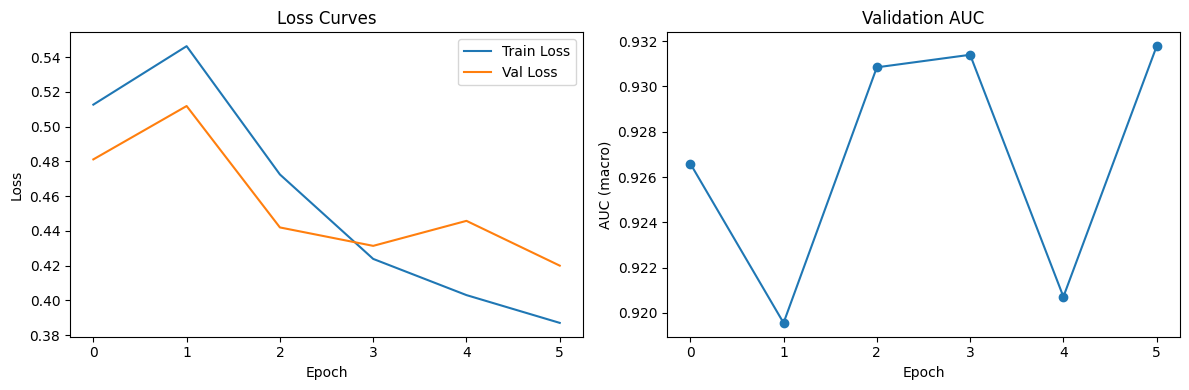

Loss gap (val - train) per epoch: [-0.03151396 -0.03444948 -0.0304933   0.00750742  0.04273522  0.03294535]
✅ No overfitting detected (gap is small).
GPU memory allocated: 1526.795776 MB
GPU memory cached:    3793.747968 MB


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Training & validation loss trend (should both go down) ---
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.legend(); plt.title('Loss Curves'); plt.xlabel('Epoch'); plt.ylabel('Loss')

# --- 2. Validation AUC improvement (should increase) ---
plt.subplot(1,2,2)
plt.plot(history['val_auc'], marker='o')
plt.title('Validation AUC'); plt.xlabel('Epoch'); plt.ylabel('AUC (macro)')
plt.tight_layout()
plt.show()

# --- 3. Overfitting check – gap between train and val loss ---
train_losses = np.array(history['train_loss'])
val_losses   = np.array(history['val_loss'])
gap = val_losses - train_losses
print("Loss gap (val - train) per epoch:", gap)
if np.any(gap > 0.5):   # arbitrary threshold; adjust
    print("⚠️ Warning: validation loss much higher than training – possible overfitting.")
else:
    print("✅ No overfitting detected (gap is small).")

# --- 4. Learning rate check (if you logged it) ---
if 'lrs' in history:    # you need to store lr each epoch
    plt.plot(history['lrs'])
    plt.title('Learning Rate Schedule'); plt.xlabel('Epoch'); plt.ylabel('LR')
    plt.show()

# --- 5. GPU memory stability (if on GPU) ---
if torch.cuda.is_available():
    print("GPU memory allocated:", torch.cuda.memory_allocated() / 1e6, "MB")
    print("GPU memory cached:   ", torch.cuda.memory_reserved() / 1e6, "MB")
    # If you want a proper leak check, run:
    #   !nvidia-smi --query-gpu=memory.used --format=csv -l 1
    # in a separate terminal.
    # In notebook, just ensure `torch.cuda.empty_cache()` is called after validation.

In [ ]:
import torch
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict() if 'optimizer' in dir() else None,
    'class_weights': class_weights,
    'history': history if 'history' in dir() else {},
    'best_auc': best_auc if 'best_auc' in dir() else None,
    'class_names': ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
}
torch.save(checkpoint, os.path.join(PROJECT_DIR, "checkpoints", "final_model.pth"))
print("✅ Full checkpoint saved.")

✅ Full checkpoint saved.


In [ ]:
torch.save(model.state_dict(), os.path.join(PROJECT_DIR, "retinal_vit_weights.pth"))
print("✅ Weights‑only file saved.")

✅ Weights‑only file saved.


In [ ]:
import json
with open(os.path.join(PROJECT_DIR, "config.json"), 'w') as f:
    json.dump({
        'class_weights': class_weights.cpu().numpy().tolist(),
        'num_classes': 5,
        'image_size': 224,
        'model_name': 'vit_base_patch16_224'
    }, f, indent=2)

if 'history' in dir():
    with open(os.path.join(PROJECT_DIR, "training_history.json"), 'w') as f:
        json.dump(history, f, indent=2)

print("✅ Config & history saved.")

✅ Config & history saved.
